In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [3]:
train.head()

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


In [4]:
train.shape

(439140, 16)

In [5]:
test.shape

(188165, 15)

In [6]:
train.isna().sum()

id                        0
Driver                    0
Compound                  0
Race                      0
Year                      0
PitStop                   0
LapNumber                 0
Stint                     0
TyreLife                  0
Position                  0
LapTime (s)               0
LapTime_Delta             0
Cumulative_Degradation    0
RaceProgress              0
Position_Change           0
PitNextLap                0
dtype: int64

In [7]:
train['PitNextLap'].value_counts()

PitNextLap
0.0    351759
1.0     87381
Name: count, dtype: int64

In [8]:
from sklearn.preprocessing import LabelEncoder

info = {}
for col in ['Driver', 'Compound', 'Race']:
    le = LabelEncoder()
    le.fit(pd.concat([train[col], test[col]]))
    train[col] = le.transform(train[col])
    test[col] = le.transform(test[col])
    info[col] = le

In [9]:
features = ['Driver', 'Compound', 'Race', 'Year', 'PitStop', 'LapNumber', 'Stint',
            'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta',
            'Cumulative_Degradation', 'RaceProgress', 'Position_Change']

X_train = train[features].values
y_train = train['PitNextLap'].values
X_test = test[features].values

In [10]:
X_train.shape

(439140, 14)

In [11]:
y_train.shape

(439140,)

In [12]:
X_test.shape

(188165, 14)

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
from sklearn.utils import shuffle

X_train, y_train = shuffle(X_train, y_train, random_state=40)

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=40)

In [16]:
X_train.shape

(351312, 14)

In [17]:
X_val.shape

(87828, 14)

In [18]:
y_train.shape

(351312,)

In [19]:
y_val.shape

(87828,)

In [20]:
from keras.layers import Dense
from keras import Sequential
from keras.optimizers import Adam

I0000 00:00:1782826590.417867     649 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782826590.418514     649 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1782826590.467100     649 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1782826592.069108     649 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782826592.069500     649 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [21]:
model = Sequential()
model.add(Dense(units=64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(units=32, activation='relu'))
model.add(Dense(units=16, activation='relu'))
model.add(Dense(units=1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1782826592.530176     649 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [22]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,585 (14.00 KB)

 Trainable params: 3,585 (14.00 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

In [24]:
model.fit(X_train, y_train, validation_data=(X_val, y_val), batch_size=512, epochs=20)

Epoch 1/20


  1/687 ━━━━━━━━━━━━━━━━━━━━ 11:12 981ms/step - accuracy: 0.7422 - loss: 0.6438

 29/687 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7932 - loss: 0.5313     

 59/687 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7948 - loss: 0.4854

 90/687 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8017 - loss: 0.4605

...

592/687 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8894 - loss: 0.2462

624/687 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8893 - loss: 0.2464

655/687 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8891 - loss: 0.2469

686/687 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8891 - loss: 0.2468

687/687 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8891 - loss: 0.2468 - val_accuracy: 0.8862 - val_loss: 0.2537


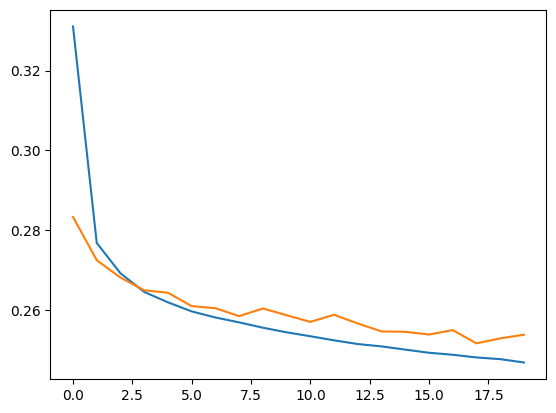

In [25]:
plt.plot(model.history.history['loss'])
plt.plot(model.history.history['val_loss'])

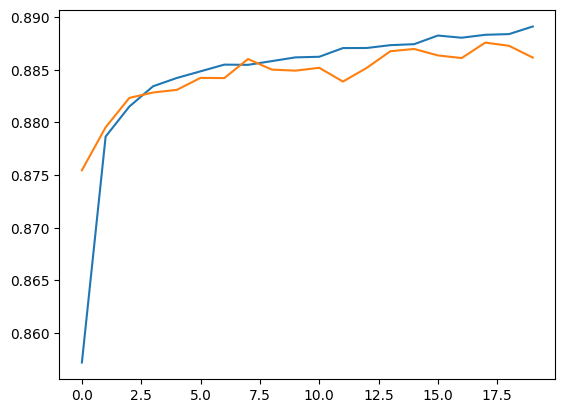

In [26]:
plt.plot(model.history.history['accuracy'])
plt.plot(model.history.history['val_accuracy'])

In [27]:
y_pred_proba = model.predict(X_test)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

   1/5881 ━━━━━━━━━━━━━━━━━━━━ 4:19 44ms/step

  67/5881 ━━━━━━━━━━━━━━━━━━━━ 4s 767us/step 

 135/5881 ━━━━━━━━━━━━━━━━━━━━ 4s 752us/step

 203/5881 ━━━━━━━━━━━━━━━━━━━━ 4s 746us/step

 272/5881 ━━━━━━━━━━━━━━━━━━━━ 4s 741us/step

...

5675/5881 ━━━━━━━━━━━━━━━━━━━━ 0s 719us/step

5744/5881 ━━━━━━━━━━━━━━━━━━━━ 0s 719us/step

5815/5881 ━━━━━━━━━━━━━━━━━━━━ 0s 719us/step

5881/5881 ━━━━━━━━━━━━━━━━━━━━ 0s 724us/step

5881/5881 ━━━━━━━━━━━━━━━━━━━━ 4s 726us/step


In [28]:
submission = pd.read_csv('sample_submission.csv')
submission['PitNextLap'] = y_pred
submission.to_csv('submission.csv', index=False)
submission.head()

,id,PitNextLap
0,439140,0
1,439141,0
2,439142,0
3,439143,0
4,439144,1
